# Live Optimization Landscape Analysis
Visualizing Hyperopt progress directly from the pickle checkpoint files for all zones and models.

In [ ]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def extract_trials_to_df(pkl_path):
    if not os.path.exists(pkl_path):
        return pd.DataFrame()
    with open(pkl_path, 'rb') as f:
        trials = pickle.load(f)
    
    data = []
    for i, trial in enumerate(trials.trials):
        if trial['result']['status'] == 'ok':
            loss = trial['result']['loss']
            # IMPORTANT: Filter out safe crash thresholds
            if loss >= 99999.0:
                continue
            
            vals = trial['misc']['vals']
            row = {'iteration': i, 'loss': loss}
            for k, v in vals.items():
                row[k] = v[0] if isinstance(v, list) and len(v) > 0 else v
            data.append(row)
    
    df = pd.DataFrame(data)
    if not df.empty and 'iteration' in df.columns:
        df = df.sort_values('iteration').reset_index(drop=True)
    return df

trials_base_dir = '../data/outputs/trials/'
if os.path.exists(trials_base_dir):
    zones = [d for d in os.listdir(trials_base_dir) if os.path.isdir(os.path.join(trials_base_dir, d))]
else:
    zones = ['AT'] # Fallback
print(f"Discovered zones: {zones}")

model_files = {
    'LEAR': 'lear_trials.pkl',
    'LightGBM': 'lgb_trials.pkl',
    'XGBoost': 'xgb_trials.pkl',
    'CatBoost': 'cat_trials.pkl',
    'RandomForest': 'rf_trials.pkl',
    'PyTorch DNN': 'dnn_trials.pkl',
    'QRA': 'qra_trials.pkl'
}


Discovered zones: ['AT', 'BE']


## 1. Cumulative Minimum Validation Loss (All Zones)

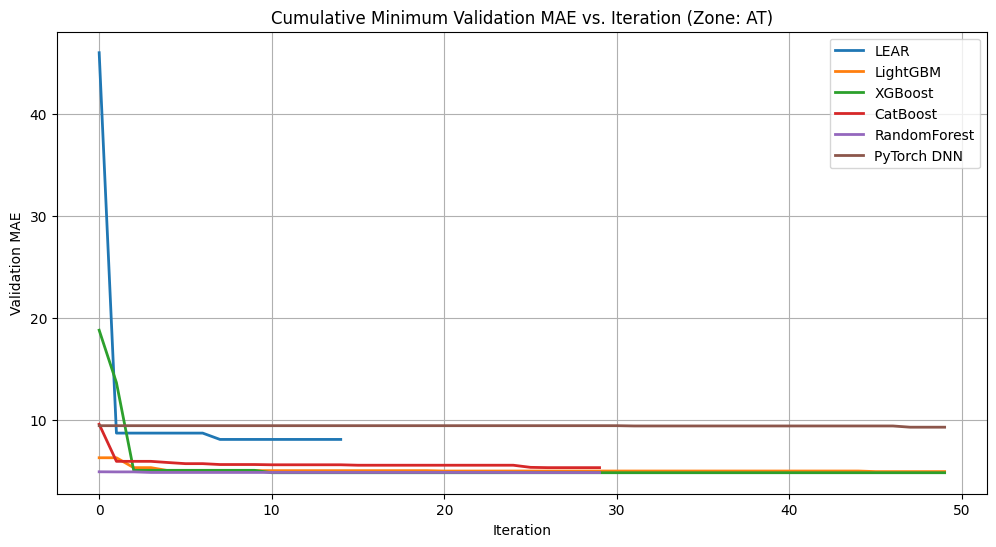

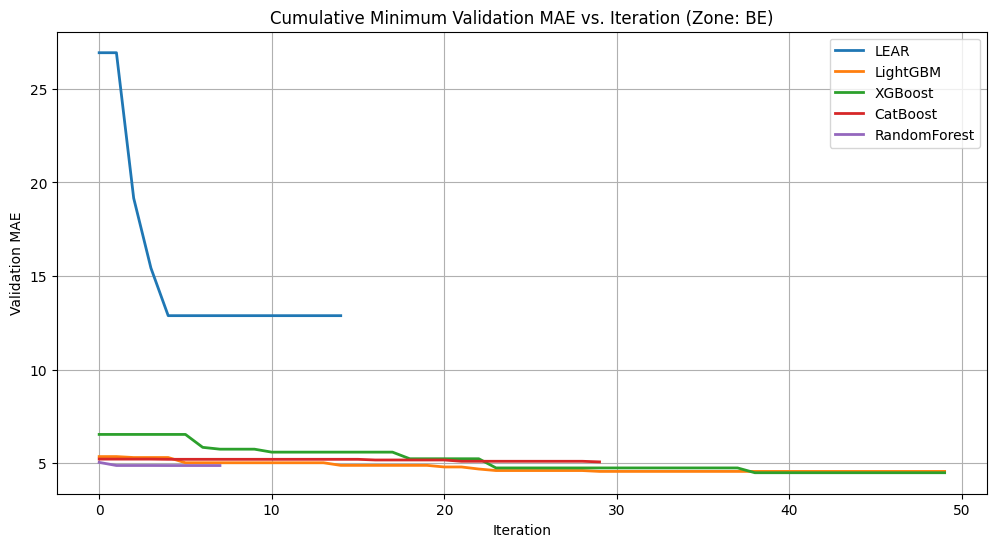

In [ ]:
for zone in zones:
    trials_dir = os.path.join(trials_base_dir, zone)
    plt.figure(figsize=(12, 6))
    
    plotted_any = False
    for model_name, filename in model_files.items():
        pkl_path = os.path.join(trials_dir, filename)
        df = extract_trials_to_df(pkl_path)
        
        if not df.empty:
            df['best_loss'] = df['loss'].cummin()
            plt.plot(df['iteration'], df['best_loss'], label=model_name, linewidth=2)
            plotted_any = True

    if plotted_any:
        plt.title(f'Cumulative Minimum Validation MAE vs. Iteration (Zone: {zone})')
        plt.xlabel('Iteration')
        plt.ylabel('Validation MAE')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        plt.close()


## 2. Hyperparameter Topology (All Models, All Zones)

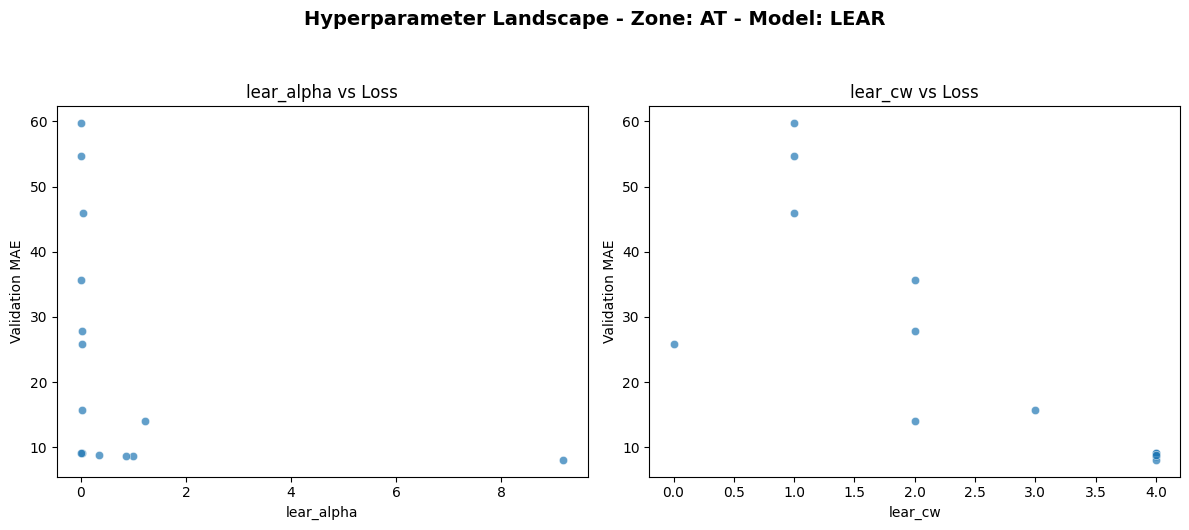

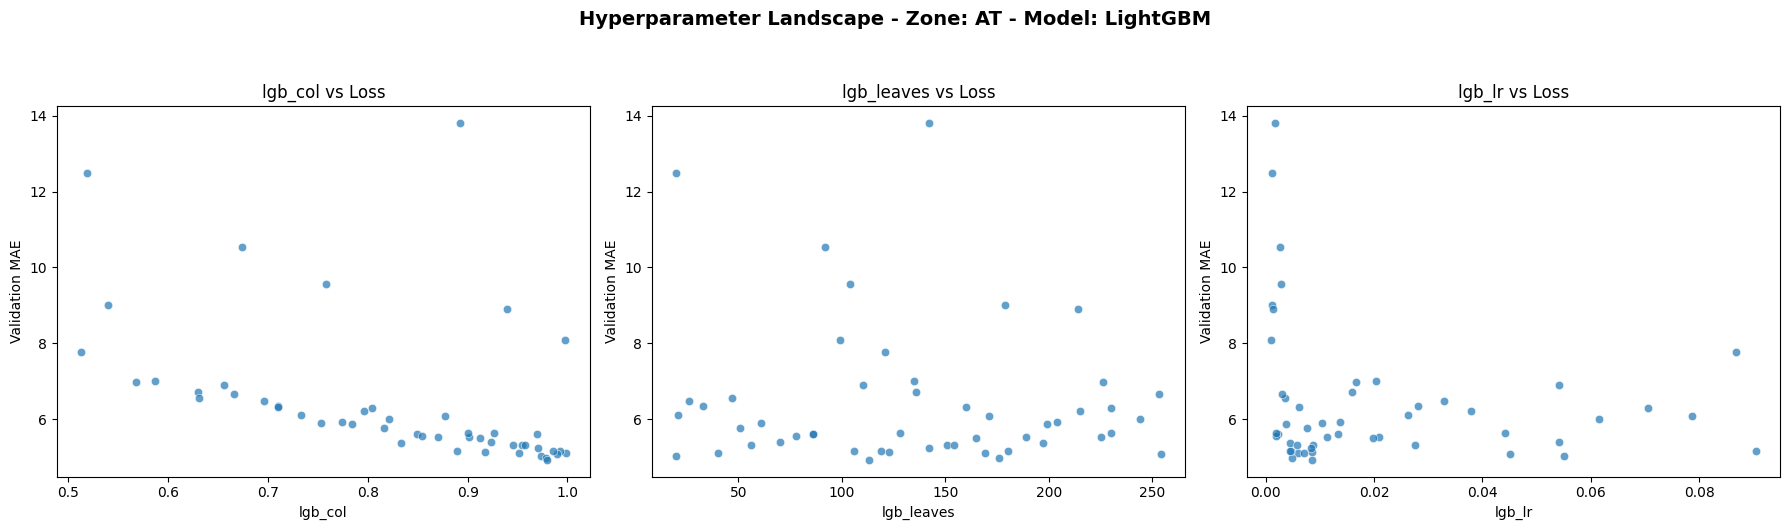

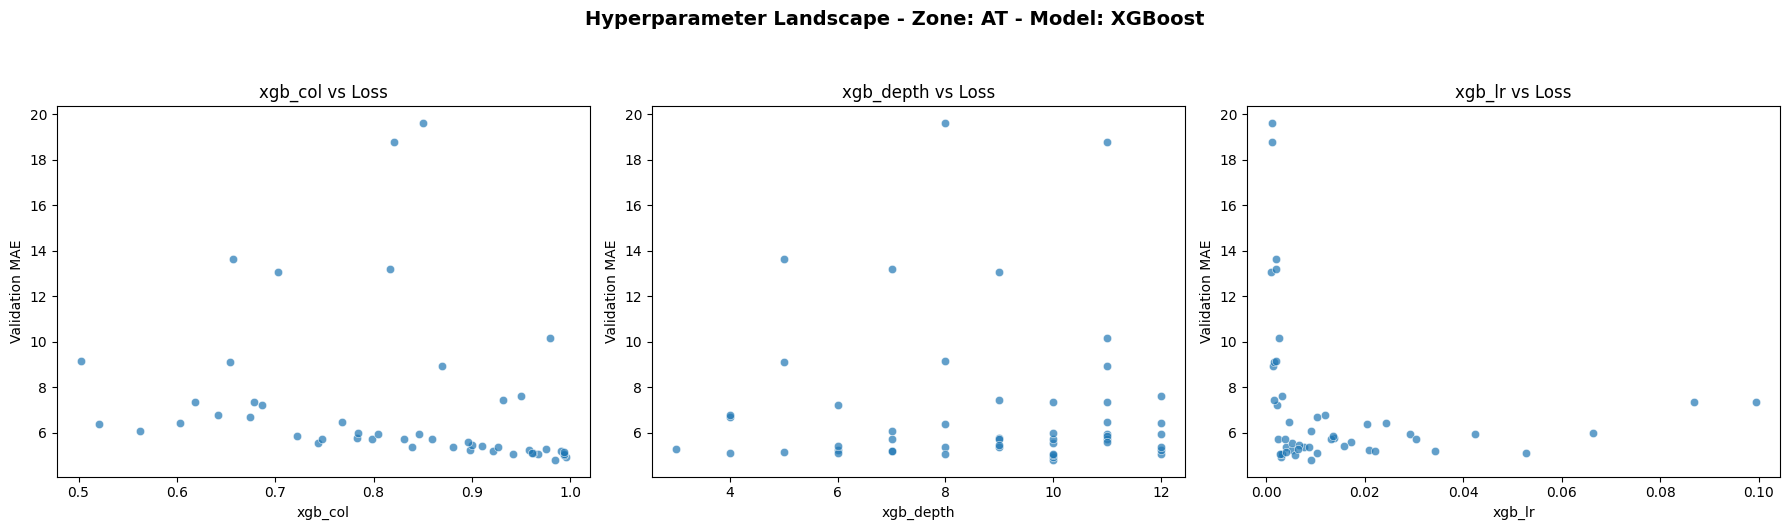

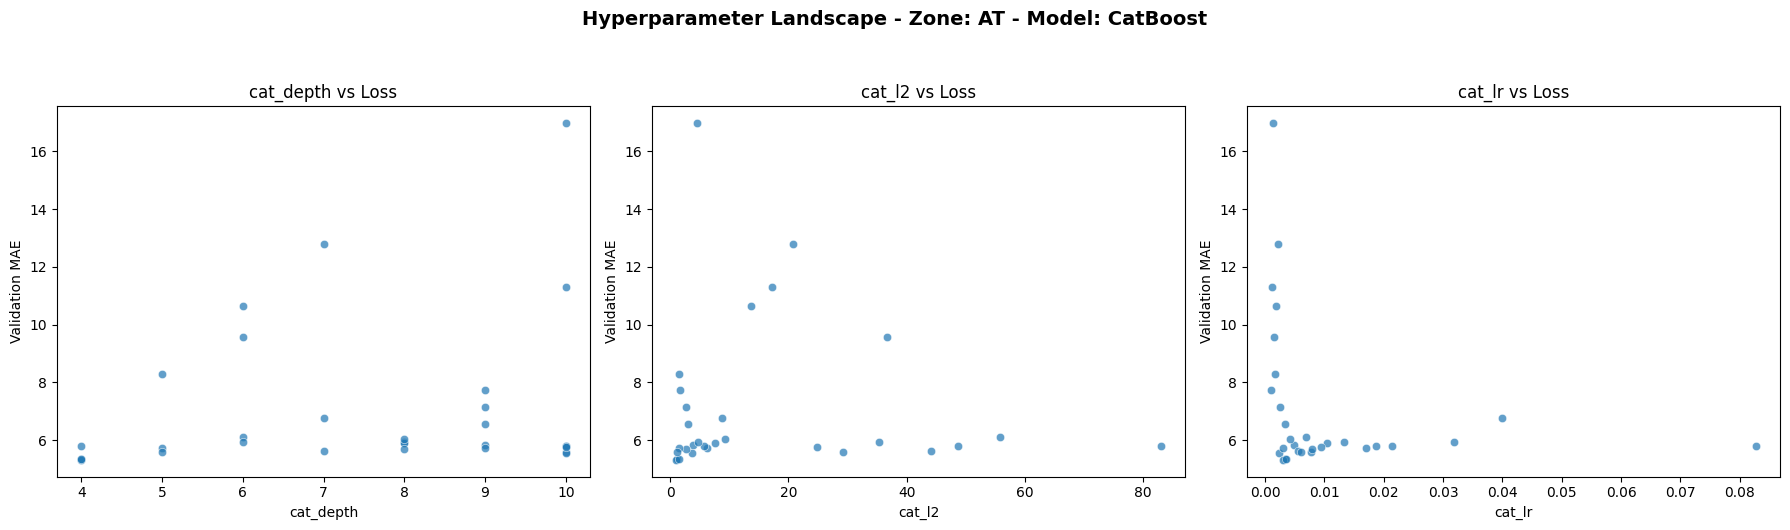

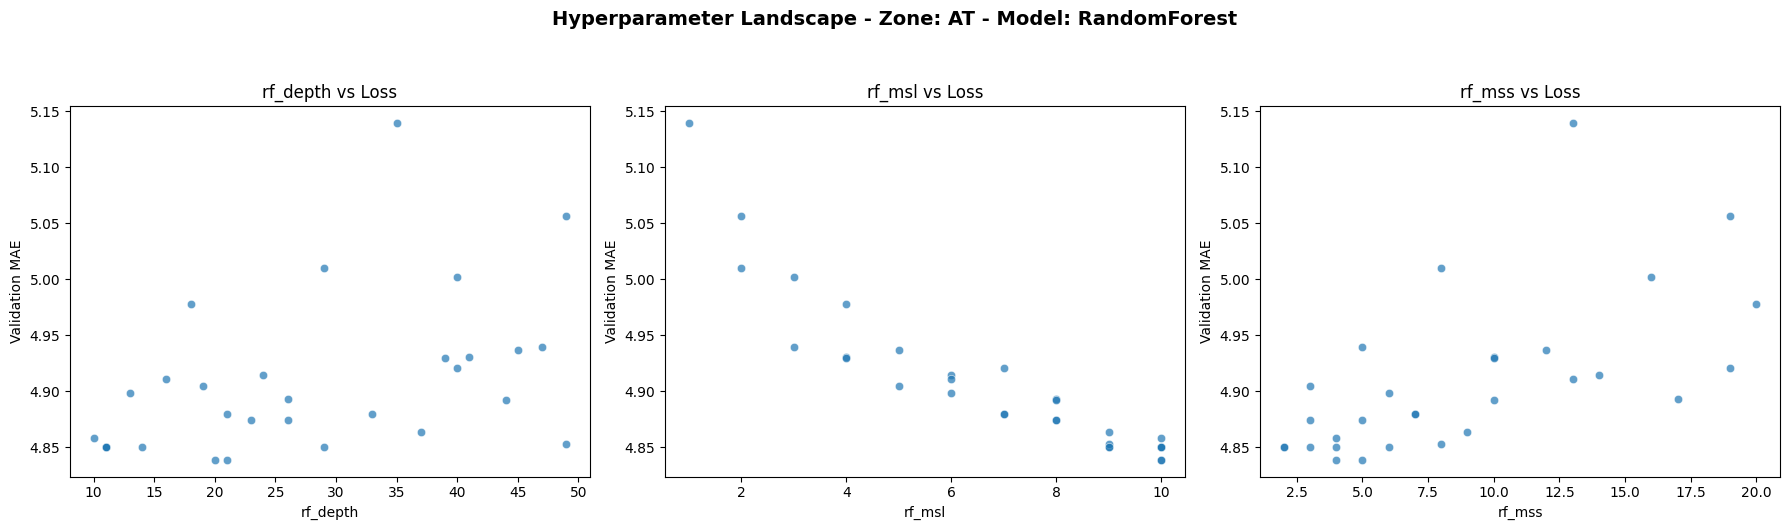

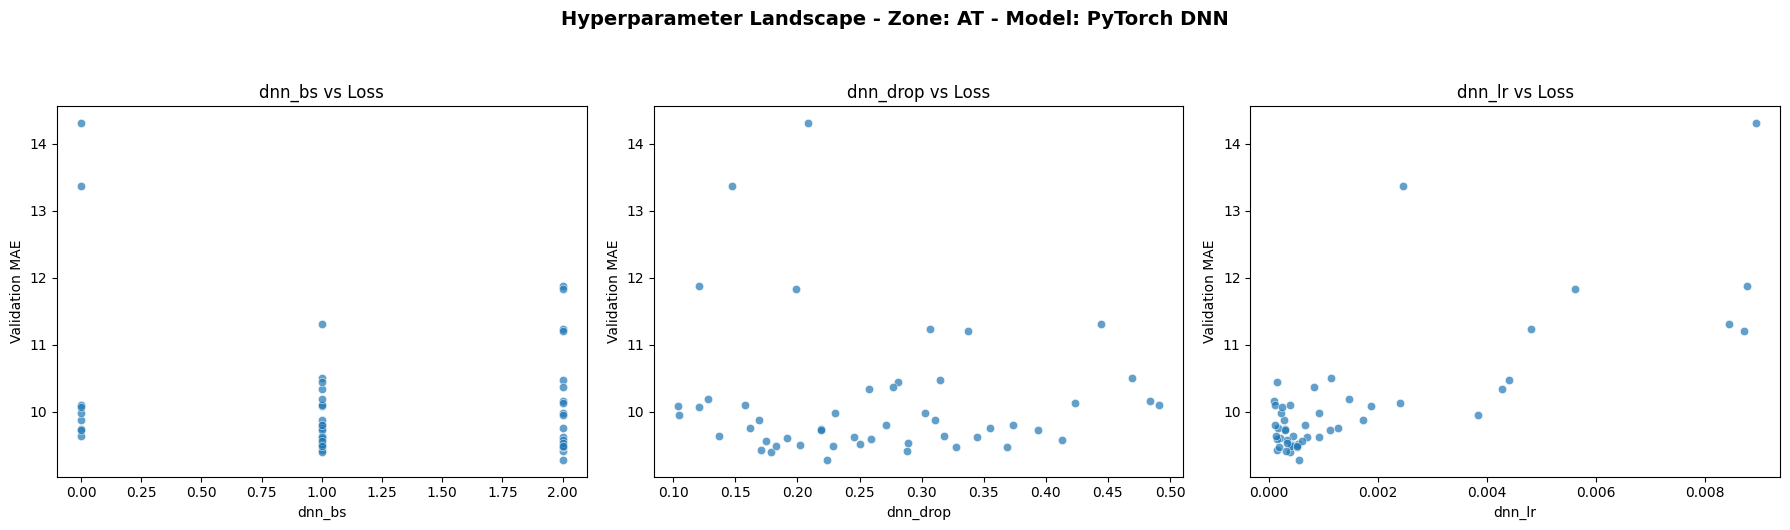

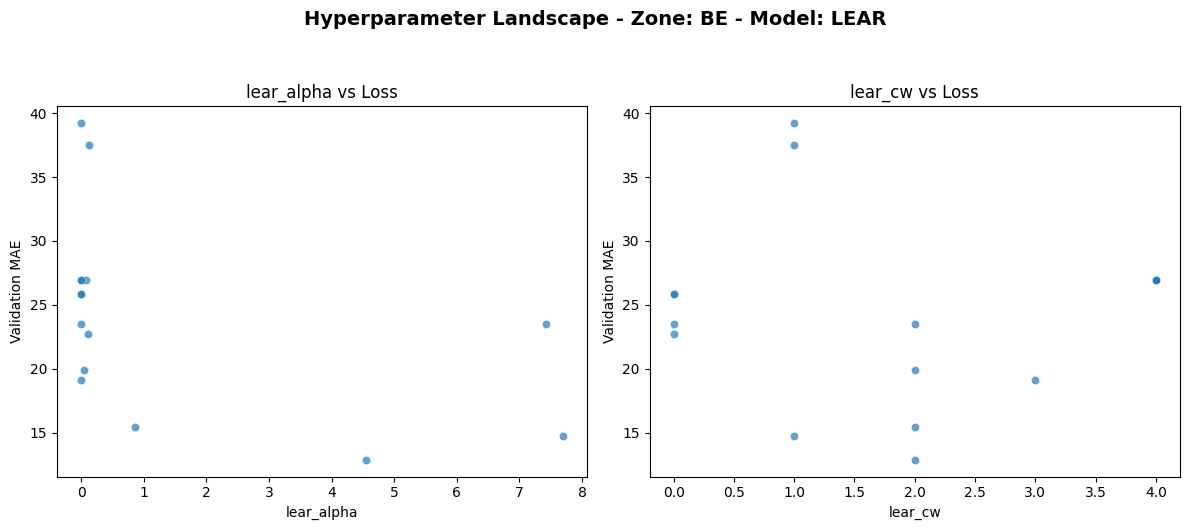

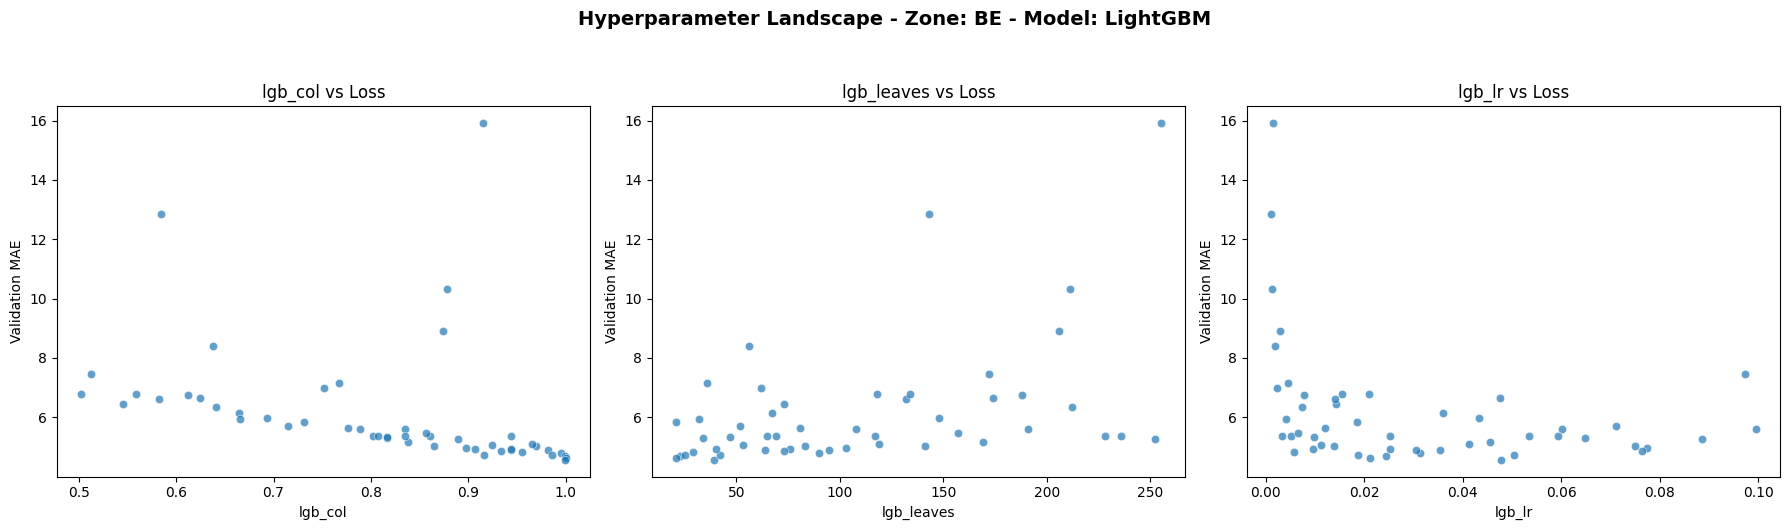

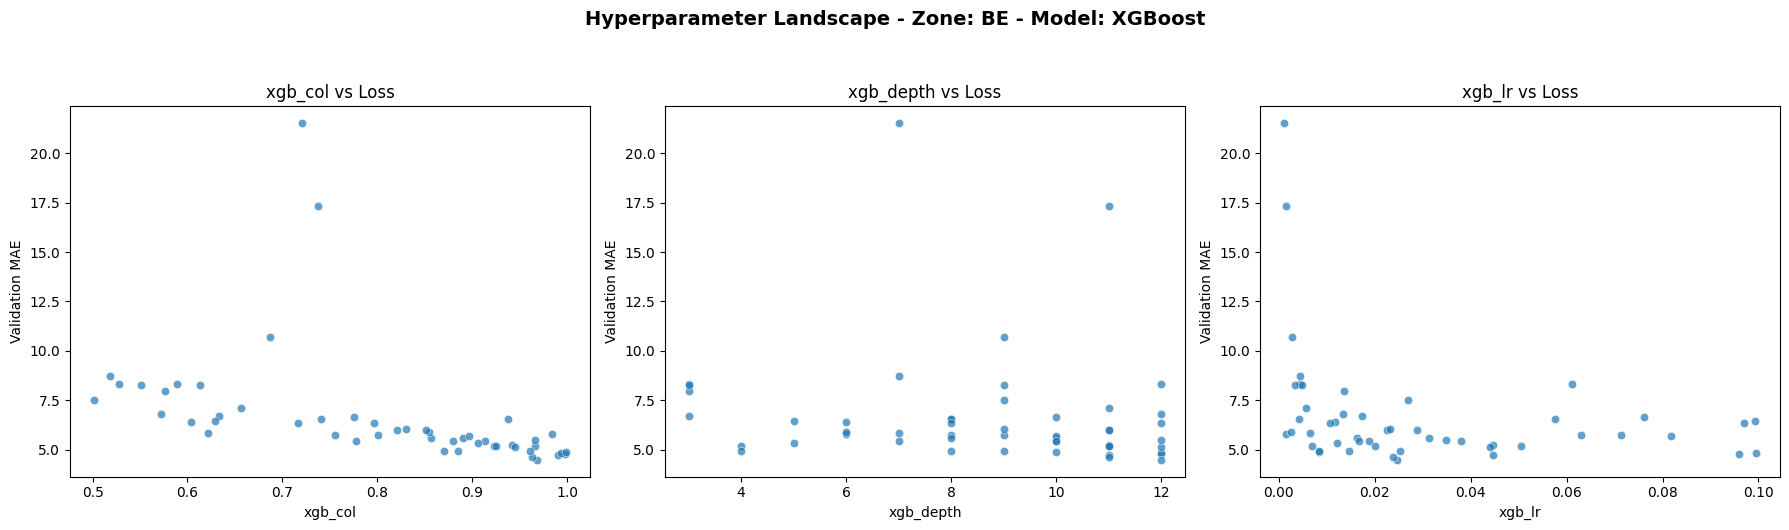

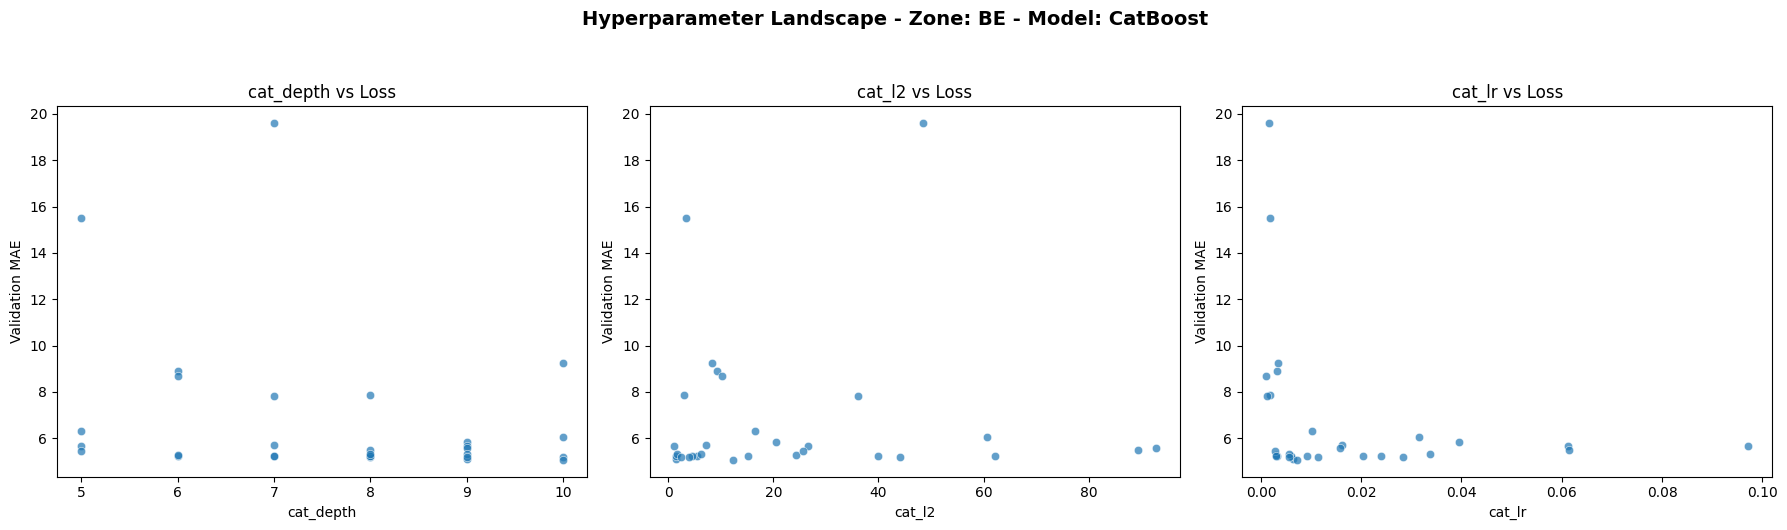

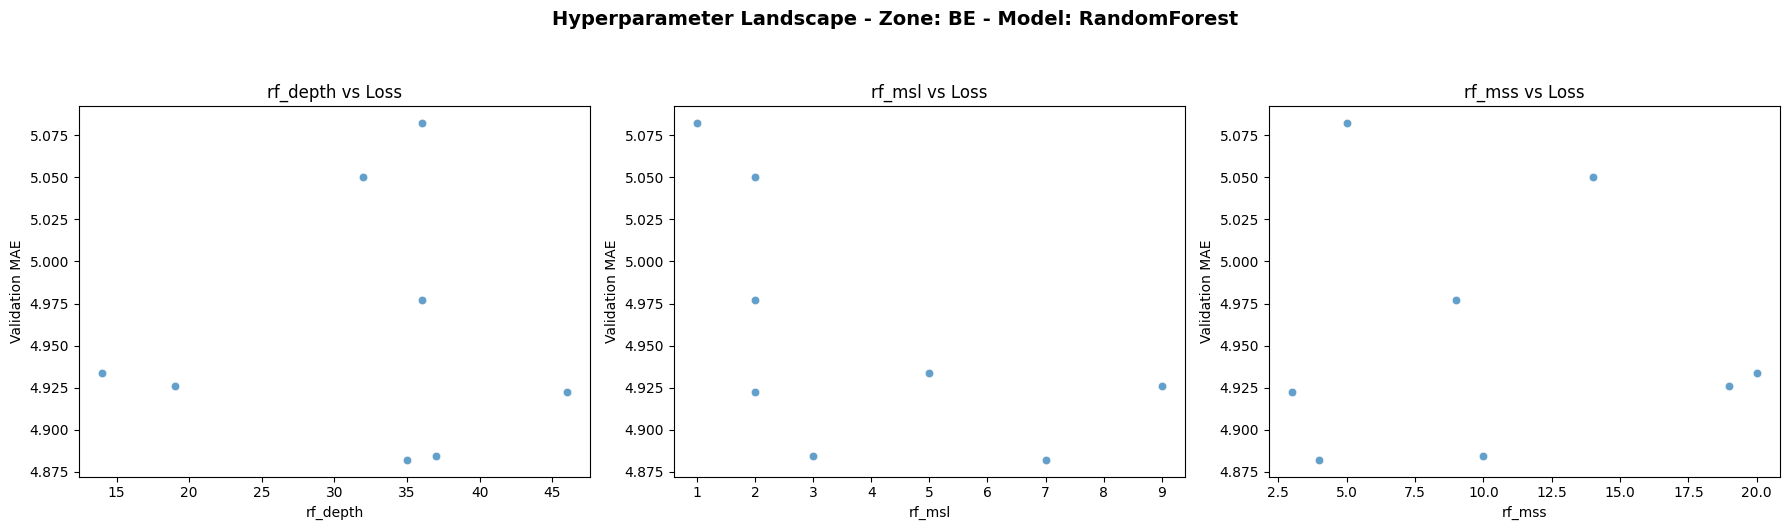

In [ ]:
for zone in zones:
    trials_dir = os.path.join(trials_base_dir, zone)
    for model_name, filename in model_files.items():
        pkl_path = os.path.join(trials_dir, filename)
        df = extract_trials_to_df(pkl_path)
        
        if not df.empty:
            params = [col for col in df.columns if col not in ['iteration', 'loss']]
            if len(params) == 0:
                continue
                
            top_params = params[:3] # Visualize at most 3 dimensions
            
            fig, axes = plt.subplots(1, len(top_params), figsize=(6*len(top_params), 5))
            if len(top_params) == 1:
                axes = [axes]
                
            for i, param in enumerate(top_params):
                sns.scatterplot(data=df, x=param, y='loss', ax=axes[i], alpha=0.7)
                axes[i].set_title(f'{param} vs Loss')
                axes[i].set_xlabel(param)
                axes[i].set_ylabel('Validation MAE')
                
            plt.suptitle(f'Hyperparameter Landscape - Zone: {zone} - Model: {model_name}', y=1.05, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
